Data generated by Todd is missing alpha's and delta's for intermediate potentials - probably to keep data clean and accurate and not get bogged down by experimental error <br>
I am going to calculate my own kinetic parameters and cross verify with Todd's data by plotting <br>
Experimental parameters: <br>
KOH concs: 0.1, 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 <br>
16 different condiitons for each basic CO oxidation: 4 different setups <br>
Potential ranges: 0.5 - 1 (vs RHE) <br>
Catalyst: Pt100 <br>
<br>
Units: <br>
Potential: V vs RHE <br>
Current: mA/cm2 <br>
<br>
This time data has replicates (4 replicates for each condition) <br>
Data was interpolated (Pchipinterpolation) to put all data sets on the same grid. <br>
Savgol is currently not working. <br>
Calculate mean and SD for each data point (current first). <br> 
Calculate mean and SD for KOs. Calculate individual KOs first and then average. <br>
Save final data and import in different workspace. <br>

Data is now truncated to i_max in each case to remove current that is affected by oxidized surface (formation of extra oxidized species like O*). <br>

# Initialization

In [21]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

import sys
import os 

utils_path = r"C:\Users\awast\OneDrive\Desktop\MKM"
data_path = r"C:\Users\awast\OneDrive\Desktop\MKM\CO_oxidation"
if utils_path not in sys.path: sys.path.append(utils_path)
import _utils

In [22]:
# Experimental conditions (Pt100 KOH) and constants

C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
trials = [1, 2, 3, 4]
conditions = list(itertools.product(C_KOH_list, P_CO_list))
conditions_trials = list(itertools.product(C_KOH_list, P_CO_list, trials))

R, T, F = 8.3145, 293.15, 96485
n = 2 # number of electrons transferred in the reaction
slope_f = np.log(10) * R * T / F # Tafel slope factor in V/decade
 
number_of_points = 58 # For a dE of 0.01 V = 10 mV

# Set to 0 to cut exactly at min alpha (current behavior)
# Set to an integer (e.g., 10) to include 10 points after the peak
# Set to None to include ALL data (no truncation)
buffer_after_min = 0

gamma = 210e-6 / F # moles of Pt per cm2, 1cm2 Pt = 210 uC 

In [23]:
# Load current density data + classification

excel_file = os.path.join(data_path, 'Summary_Pt_replicates.xlsx')
experiments = {}
for C_KOH in C_KOH_list: 
    for trial in trials: 
        sheet_name = f'{int(C_KOH*1000)} mM KOH - Trial {trial}'
        df = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
        for i, P_CO in enumerate(P_CO_list): 
            col_idx = i * 2
            subset = df.iloc[2:, col_idx : col_idx+2].copy()
            subset.columns = ['E', 'j']
            # Force numeric, coerce bad values/text to NaN, then drop
            subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
            subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
            subset = subset.dropna()
            experiments[(C_KOH, P_CO, trial)] = subset

# Smoothing and Interpolating

In [24]:
# Block 4:
# 1. Find the absolute extremes to build the master SHE grid safely
all_min_SHE = min(df['E'].min() - slope_f * (14 + np.log10(C)) for (C, _, _), df in experiments.items())
all_max_SHE = max(df['E'].max() - slope_f * (14 + np.log10(C)) for (C, _, _), df in experiments.items())

# Calculate physically constant dE and establish a universal master SHE grid
dE = (all_max_SHE - all_min_SHE) / (number_of_points - 1)
master_E_grid = np.arange(np.floor(all_min_SHE/dE)*dE, np.ceil(all_max_SHE/dE)*dE + dE, dE)

experiments_interp = {}
experiments_mean = {}
untruncated_data = {} 

for P_CO in P_CO_list:
    for C_KOH in C_KOH_list:
        
        # CHANGED: Get LOCAL bounds for just these 3 trials to avoid over-truncating
        local_min_RHE = max(experiments[(C_KOH, P_CO, t)]['E'].min() for t in trials)
        local_max_RHE = min(experiments[(C_KOH, P_CO, t)]['E'].max() for t in trials)
        
        # 2. Convert to SHE and setup the common interpolated grid
        E_ref = -slope_f * (14 + np.log10(C_KOH))
        
        # Select points strictly from the master grid that fall within THIS condition's range
        mask = (master_E_grid >= (local_min_RHE + E_ref) - 1e-9) & (master_E_grid <= (local_max_RHE + E_ref) + 1e-9)
        E_grid_SHE = master_E_grid[mask]
        
        buffer_pts = buffer_after_min if buffer_after_min is not None else 0
        
        trials_data = {}
        cutoffs = []
        for trial in trials:
            cond = (C_KOH, P_CO, trial)
            df = experiments[cond]
            # CHANGED: Truncate to the local bounds, not the global bounds
            df_trunc = df[(df['E'] >= local_min_RHE) & (df['E'] <= local_max_RHE)]
            
            # 3. Interpolate to coarser aligned SHE grid
            rate_interp = PchipInterpolator(df_trunc['E'] + E_ref, df_trunc['j'] / (1000 * n * F * gamma))(E_grid_SHE)
            log_rate_interp = np.log(rate_interp)
            
            # 3b. Smoothen data (SG - commented out for now)
            # window = min(11, len(log_rate_interp) if len(log_rate_interp) % 2 != 0 else len(log_rate_interp) - 1)
            # log_rate_interp = savgol_filter(log_rate_interp, window_length=window, polyorder=3)
            # rate_interp = np.exp(log_rate_interp)
            
            # 4. Calculate alpha and find truncation index
            alpha = (R * T / F) * np.gradient(log_rate_interp, E_grid_SHE)
            if buffer_after_min is not None:
                cutoffs.append(np.argmin(alpha[5:]) + 5 + buffer_pts)
            else:
                cutoffs.append(len(E_grid_SHE))
                
            trials_data[trial] = {'rate': rate_interp, 'log_rate': log_rate_interp}
            
        # 5. Truncate uniformly to the max cutoff to ensure equal lengths
        final_cut = min(max(cutoffs), len(E_grid_SHE))
        E_final = E_grid_SHE[:final_cut]
        
        rate_mat, log_rate_mat = [], []
        untrunc_rate_mat = []
        
        # 6. Build final datasets and average
        for trial in trials:
            cond = (C_KOH, P_CO, trial)
            
            # Save UNTRUNCATED data for Blocks 5, 6, and 7
            untruncated_data[cond] = {
                'E': E_grid_SHE,
                'rate': trials_data[trial]['rate'],
                'log_rate': trials_data[trial]['log_rate'],
                'j': trials_data[trial]['rate'] * (1000 * n * F)
            }
            
            untrunc_rate_mat.append(trials_data[trial]['rate'])

            # Truncated arrays for PyMC
            r_final = trials_data[trial]['rate'][:final_cut]
            lr_final = trials_data[trial]['log_rate'][:final_cut]
            
            experiments_interp[cond] = {
                'E': E_final,
                'rate': r_final,
                'log_rate': lr_final,
                'j': r_final * (1000 * n * F)
            }
            rate_mat.append(r_final)
            log_rate_mat.append(lr_final)
            
        experiments_mean[(C_KOH, P_CO)] = {
            'E': E_final,
            'rate': np.mean(rate_mat, axis=0),
            'rate_SD': np.std(rate_mat, axis=0, ddof=1) / np.sqrt(len(trials)),  # SD for sample -> SD for mean
            'log_rate': np.mean(log_rate_mat, axis=0),
            'log_rate_SD': np.std(log_rate_mat, axis=0, ddof=1) / np.sqrt(len(trials)),  # SD for sample -> SD for mean
            'untruncated_E': E_grid_SHE, 
            'untruncated_rate': np.mean(untrunc_rate_mat, axis=0),
            'untruncated_rate_SD': np.std(untrunc_rate_mat, axis=0, ddof=1)
        }

# Currents

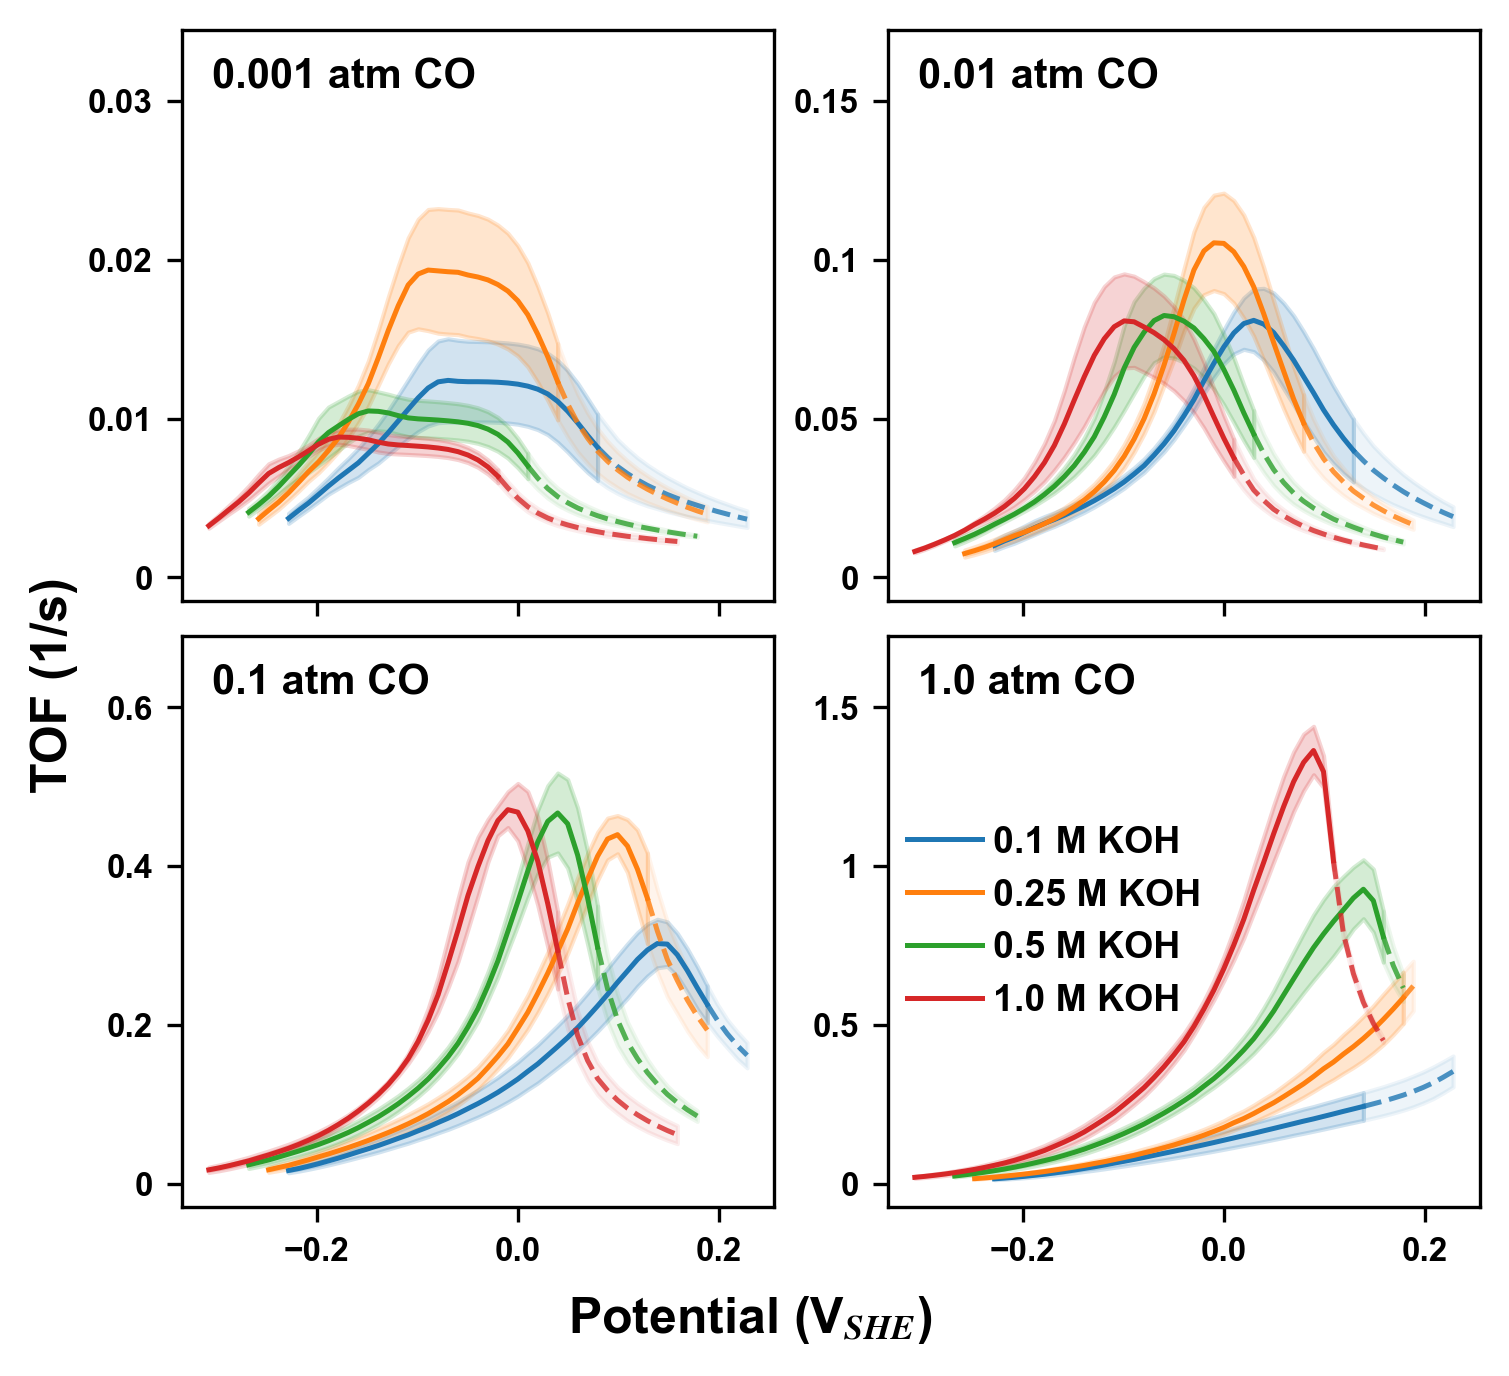

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# --- CUSTOMIZATION VARIABLES ---
label_fs = 12
legend_fs = 9
sub_text_fs = 10
untrunc_alpha = 0.08

# --- MANUAL MAX Y-AXIS BOUNDS ---
# Define the maximum Y value for each subplot. 
# The code will automatically create 4 ticks: 0, 1/3, 2/3, and Max.
y_limits = {
    "0.001 atm CO": 0.03,
    "0.01 atm CO":  0.15,
    "0.1 atm CO":   0.6,
    "1.0 atm CO":   1.5
}
# -------------------------------

fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
titles = ["0.001 atm CO", "0.01 atm CO", "0.1 atm CO", "1.0 atm CO"]
n_trials = len(trials)

for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(2, 2, i + 1)
    title_str = titles[i]
    
    for C_KOH in C_KOH_list:
        cond = (C_KOH, P_CO)
        d = experiments_mean[cond]
        
        # 1. Solid (Truncated Data) - using your original alpha/linewidth
        line = ax.plot(d['E'], d['rate'], label=f'{C_KOH} M KOH', linewidth=1.2)
        color = line[0].get_color()
        ax.fill_between(d['E'], d['rate'] - d['rate_SD'], d['rate'] + d['rate_SD'], 
                        color=color, alpha=0.2)
        
        # 2. Dashed (Untruncated Tail) - Smooth transition & SEM
        boundary_E = np.max(d['E'])
        mask = d['untruncated_E'] >= boundary_E 
        
        E_tail = d['untruncated_E'][mask]
        tail_SEM = d['untruncated_rate_SD'][mask] / np.sqrt(n_trials)
        rate_tail = d['untruncated_rate'][mask]
        
        ax.plot(E_tail, rate_tail, color=color, linewidth=1.2, linestyle='--', alpha=0.8)
        ax.fill_between(E_tail, rate_tail - tail_SEM, rate_tail + tail_SEM, 
                        color=color, alpha=untrunc_alpha)

    # --- Manual Scaling & Ticks (Matching your original 3-step logic) ---
    max_tick = y_limits[title_str]
    step = max_tick / 3
    ticks = [0, step, 2 * step, max_tick]
    margin = 0.05 * max_tick
    
    ax.set_yticks(ticks)
    # Extra headroom (margin * 3) ensures the subplot text never overlaps the data
    ax.set_ylim(-margin, max_tick + (margin * 3))
    # Format ticks cleanly to avoid floating point visual noise
    ax.set_yticklabels([f'{val:.3g}' for val in ticks])
    ax.tick_params(axis='both', labelsize=8)
    
    # Common X-Axis: Hide tick labels for the top row
    if i < 2:
        ax.set_xticklabels([])
    
    # Subplot Bold Text
    ax.text(0.05, 0.95, title_str, transform=ax.transAxes, 
            fontsize=sub_text_fs, fontweight='bold', verticalalignment='top')

    # Legend placement
    if i == 3: 
        ax.legend(fontsize=legend_fs, frameon=False, loc='center left')

# --- Common Bold Axis Labels ---
# supxlabel/supylabel work perfectly with tight_layout to center across the whole figure
fig.supxlabel(r'Potential (V$_{SHE}$)', fontsize=label_fs, fontweight='bold')
fig.supylabel('TOF (1/s)', fontsize=label_fs, fontweight='bold')

plt.tight_layout(pad=0.4)
plt.savefig('Pt100_KOH_TOF_curves.svg', dpi=300)
plt.show()

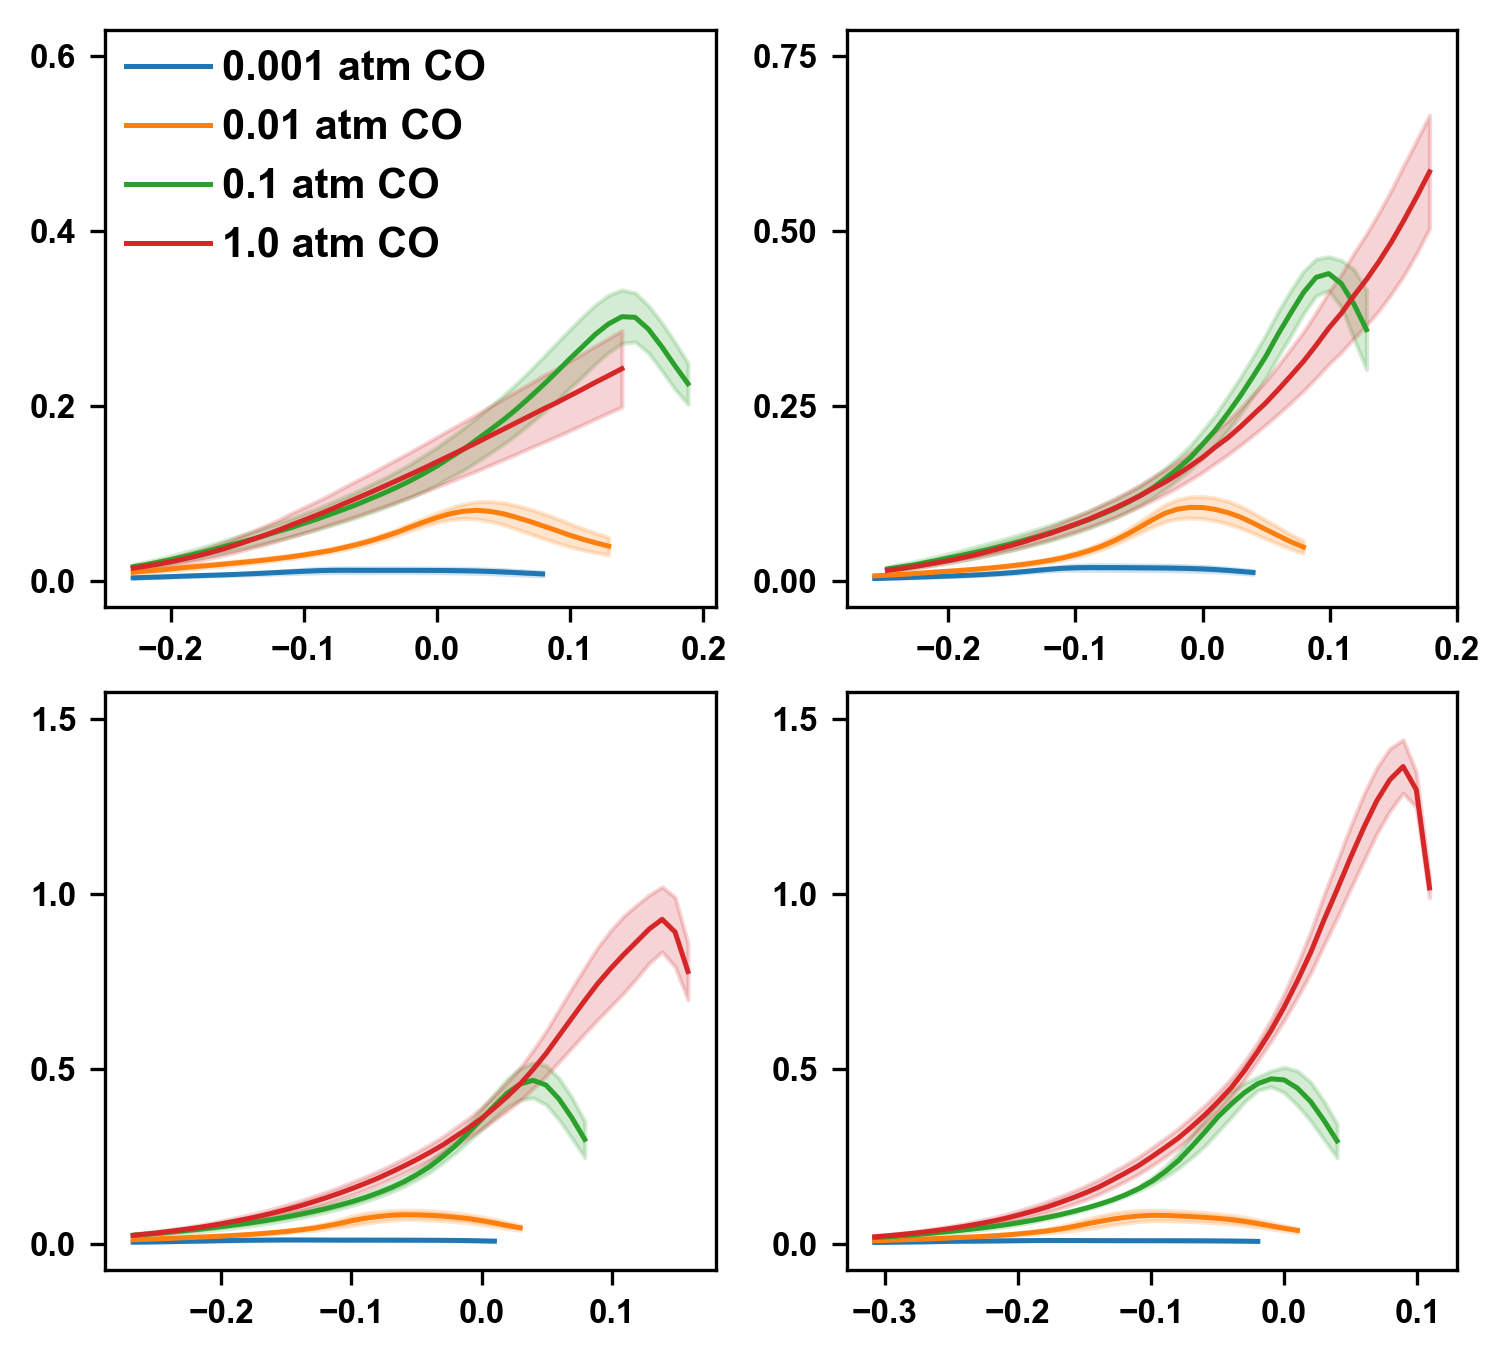

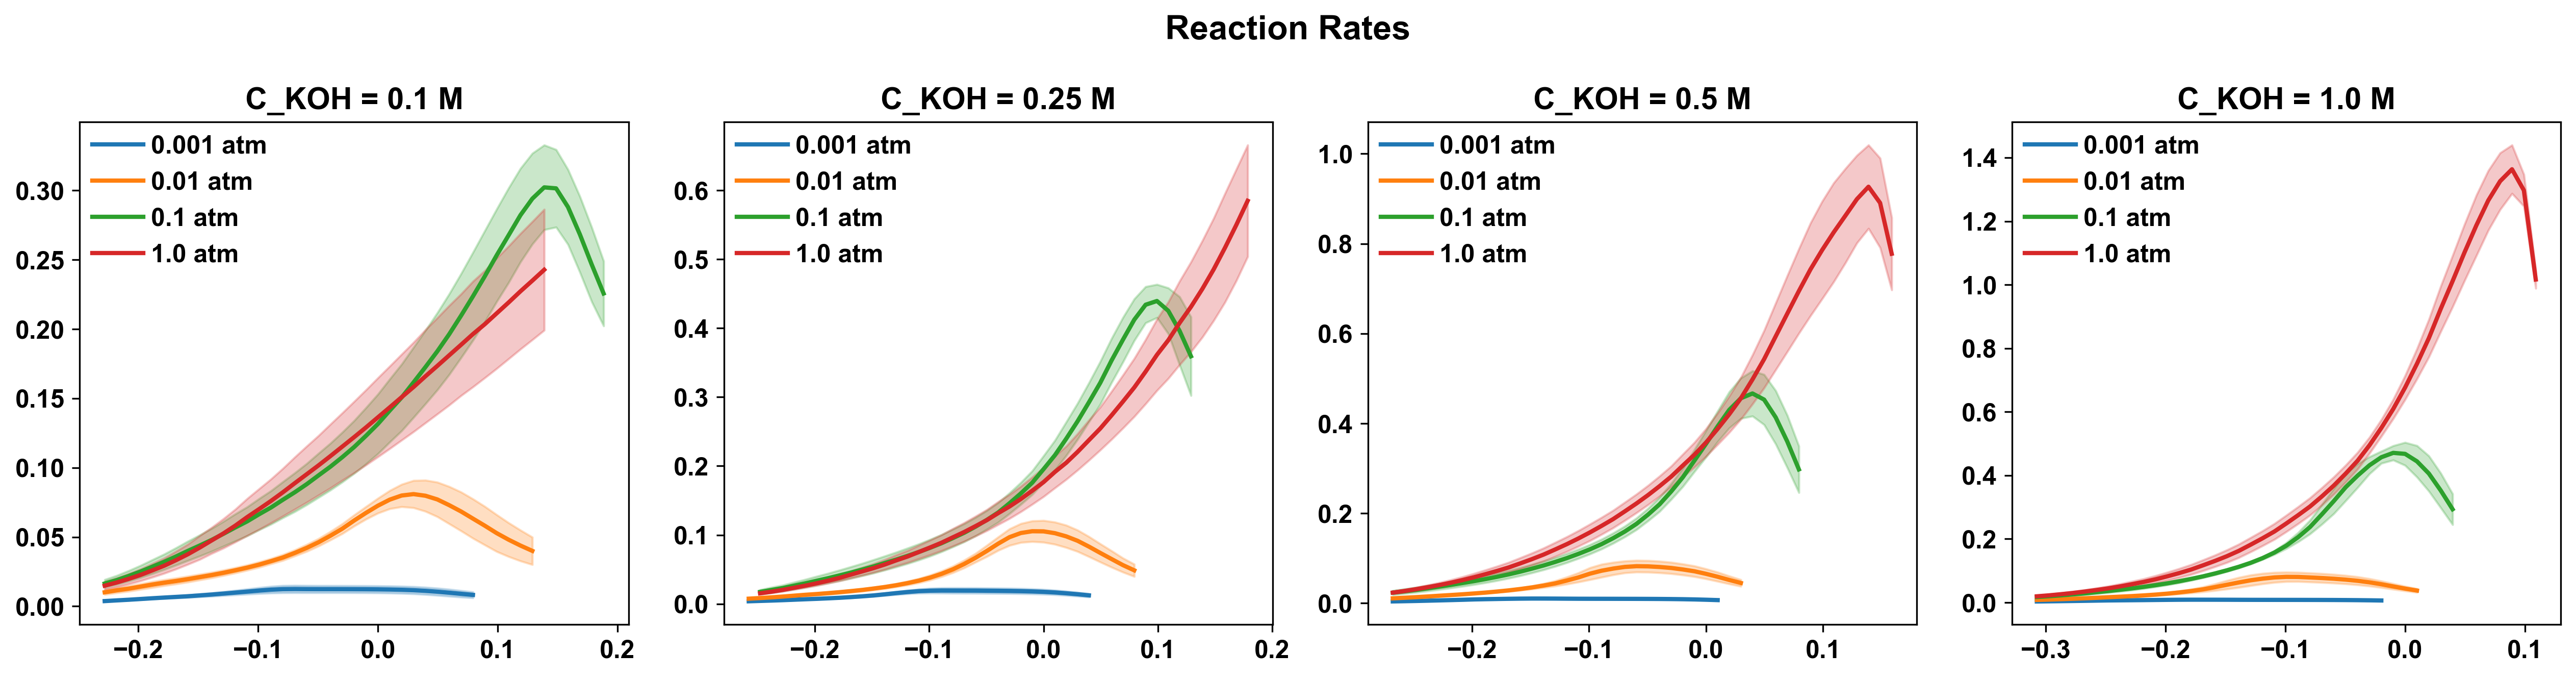

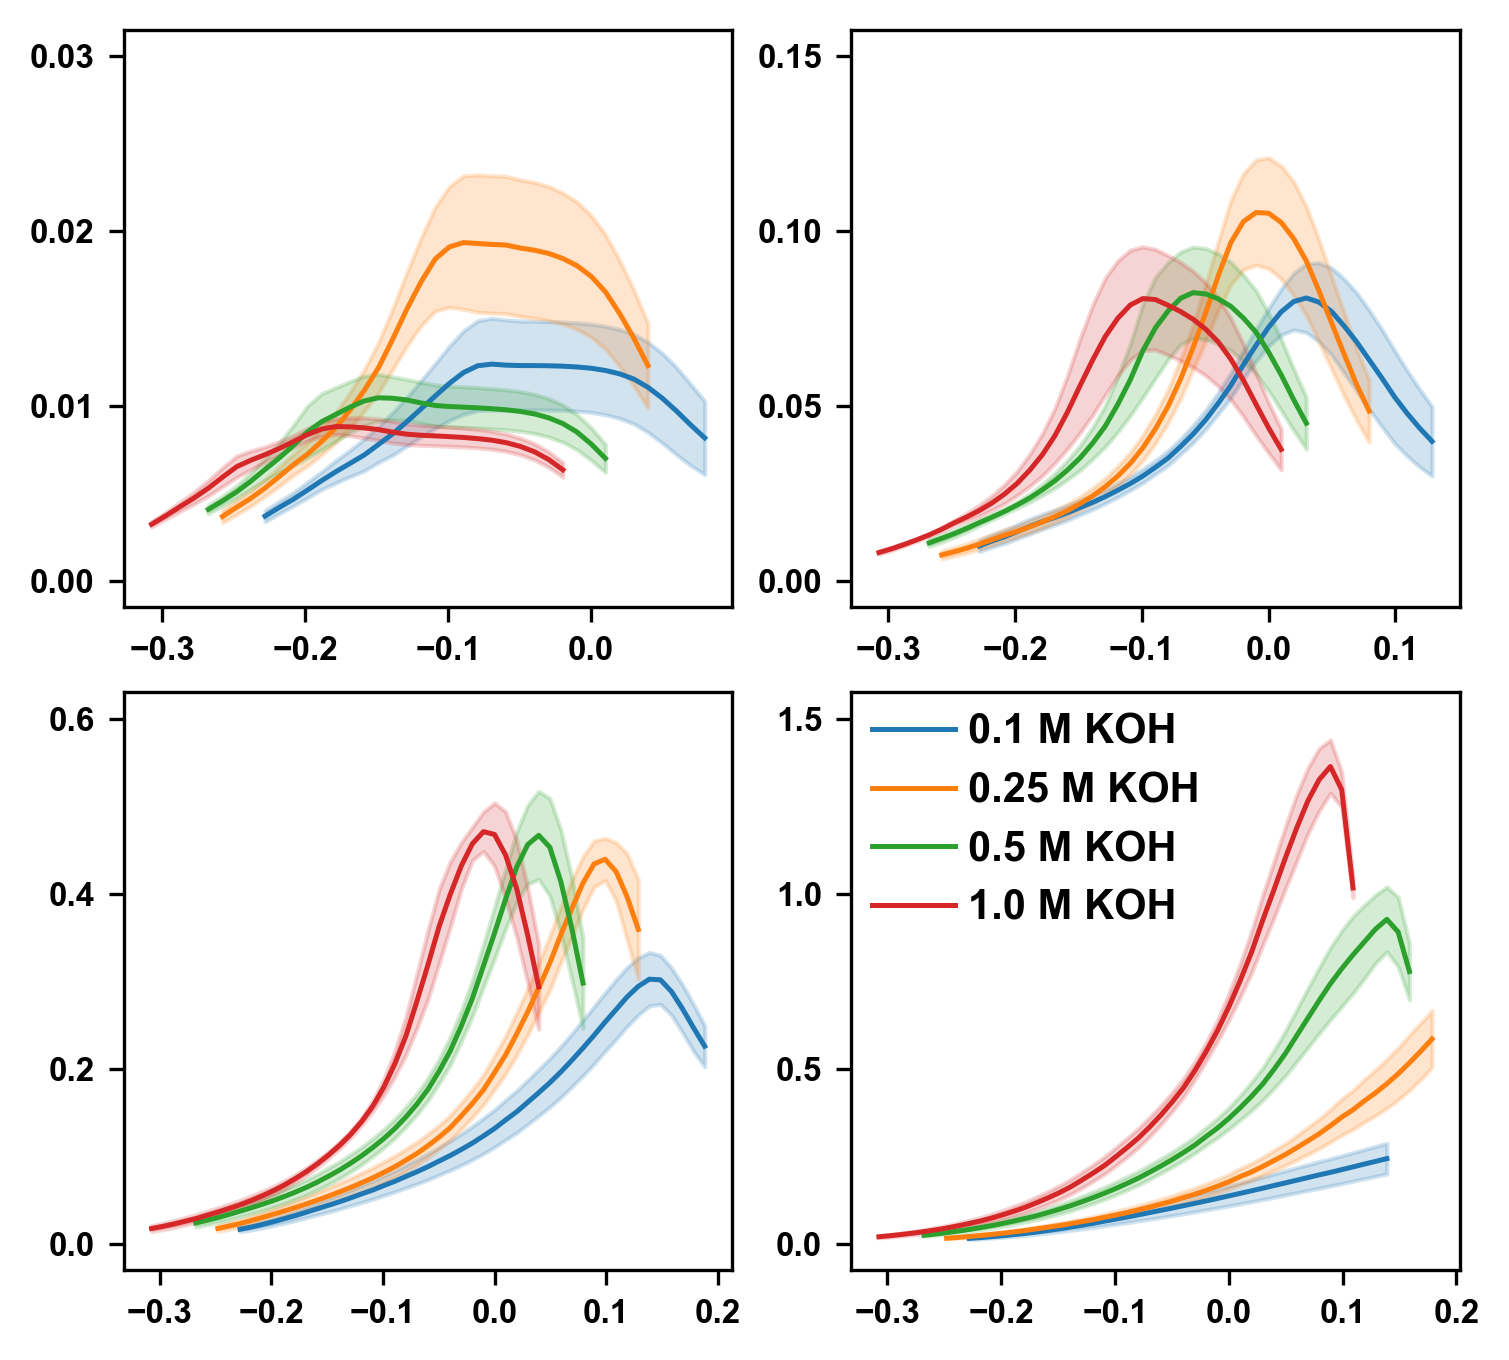

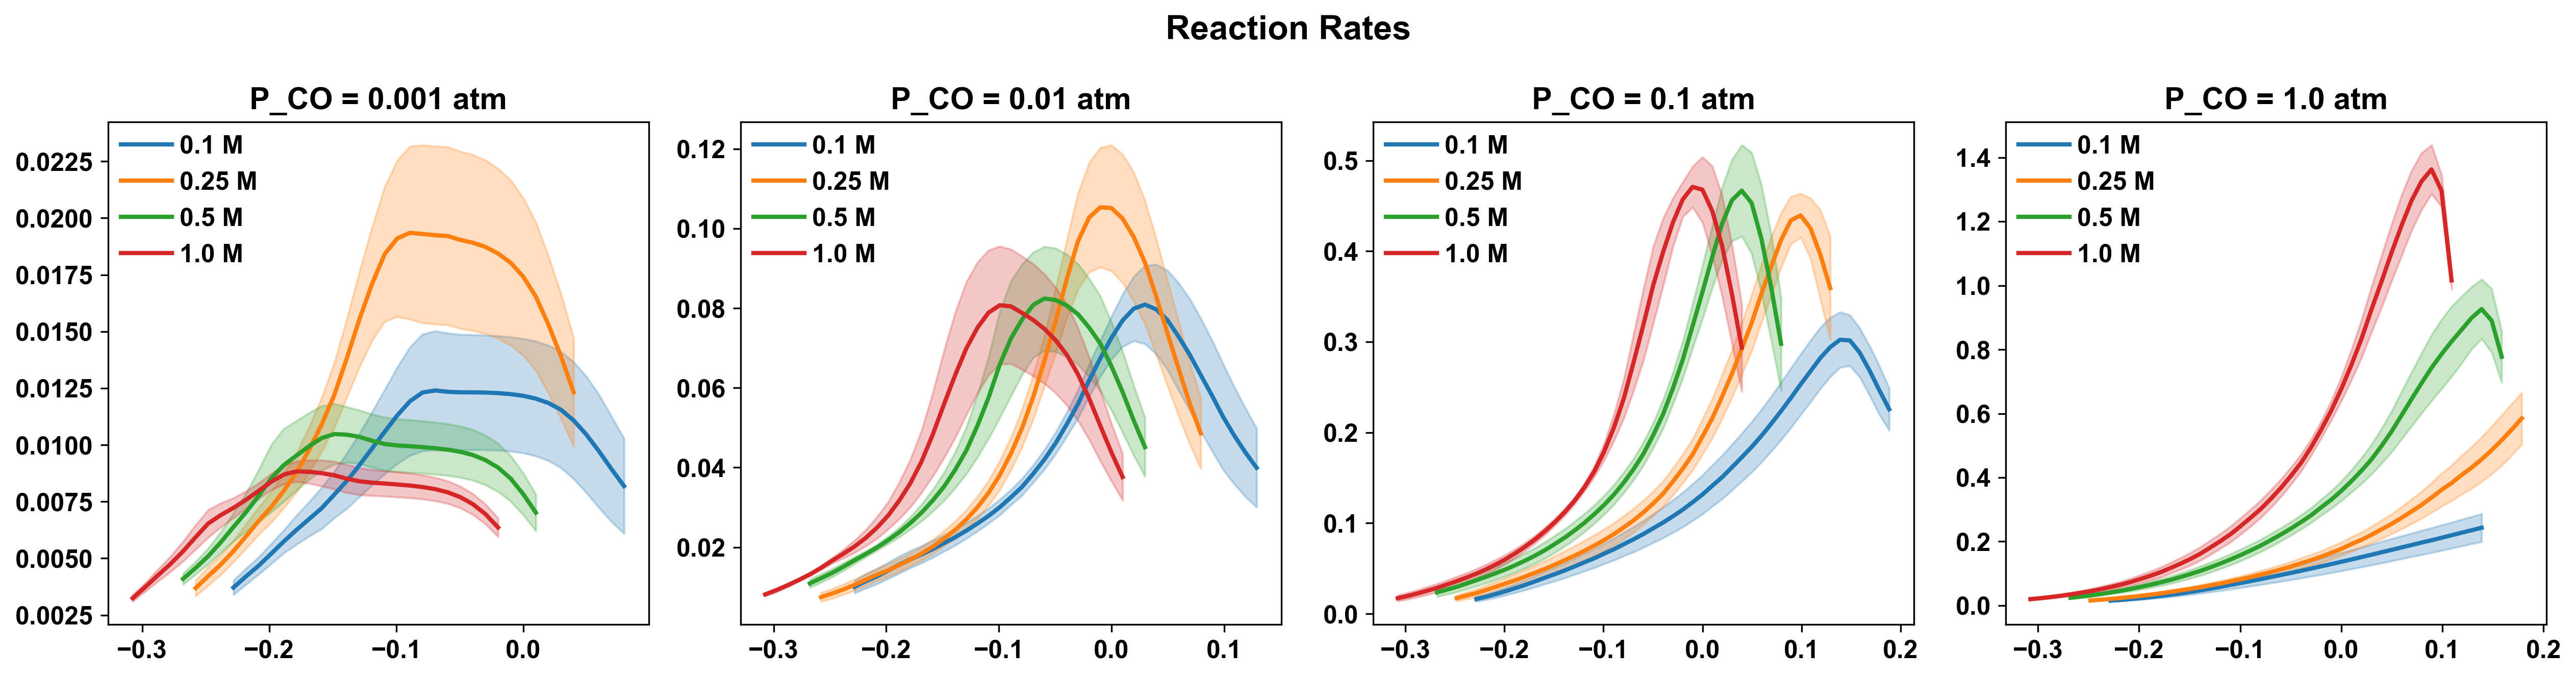

In [6]:

fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1)
    max_y = 0
    for P_CO in P_CO_list:
        E = experiments_mean[(C_KOH, P_CO)]['E']
        j = experiments_mean[(C_KOH, P_CO)]['rate']
        j_SD = experiments_mean[(C_KOH, P_CO)]['rate_SD']
        line = ax.plot(E, j, label=f'{P_CO} atm CO', linewidth=1.2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.2)
        max_y = max(max_y, np.max(j + j_SD))    
    mag = 10 ** np.floor(np.log10(max_y / 3))
    norm_step = (max_y / 3) / mag
    nice_step = 1 if norm_step <= 1 else 2 if norm_step <= 2 else 2.5 if norm_step <= 2.5 else 5 if norm_step <= 5 else 10
    step = nice_step * mag
    max_tick = 3 * step
    margin = 0.05 * max_tick
    ax.set_yticks([0, step, 2 * step, max_tick])
    ax.set_ylim(-margin, max_tick + margin)
    ax.tick_params(axis='both', labelsize=8)
    if i == 0: ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Reaction Rates', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1)
    plt.title(f'C_KOH = {C_KOH} M')
    for P_CO in P_CO_list:
        E = experiments_mean[(C_KOH, P_CO)]['E']
        j = experiments_mean[(C_KOH, P_CO)]['rate']
        j_SD = experiments_mean[(C_KOH, P_CO)]['rate_SD']
        line = ax.plot(E, j, label=f'{P_CO} atm', linewidth=2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.25)
    plt.legend()
plt.tight_layout()


fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(2, 2, i + 1)
    max_y = 0
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        j = experiments_mean[condition]['rate']
        j_SD = experiments_mean[condition]['rate_SD'] 
        line = ax.plot(E, j, label=f'{C_KOH} M KOH', linewidth=1.2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.2)
        max_y = max(max_y, np.max(j + j_SD))    
    mag = 10 ** np.floor(np.log10(max_y / 3))
    norm_step = (max_y / 3) / mag
    nice_step = 1 if norm_step <= 1 else 2 if norm_step <= 2 else 2.5 if norm_step <= 2.5 else 5 if norm_step <= 5 else 10
    step = nice_step * mag
    max_tick = 3 * step
    margin = 0.05 * max_tick
    ax.set_yticks([0, step, 2 * step, max_tick])
    ax.set_ylim(-margin, max_tick + margin)
    ax.tick_params(axis='both', labelsize=8)
    if i == 3: ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Reaction Rates', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'P_CO = {P_CO} atm')
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        j = experiments_mean[condition]['rate']
        j_SD = experiments_mean[condition]['rate_SD'] 
        line = ax.plot(E, j, label=f'{C_KOH} M', linewidth=2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.25)
    plt.legend()
plt.tight_layout()

In [7]:
# Load Todd's alpha data + classification

alpha_todd_raw = pd.read_excel(excel_file, sheet_name='TC')
alpha_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 3
    subset = alpha_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'alpha', 'alpha_SD'] # in RHE
    subset = subset.dropna()
    alpha_todd[(C_KOH, P_CO)] = subset
    
    E_ref = 0 - slope_f*(14 + np.log10(C_KOH))
    alpha_todd[(C_KOH, P_CO)]['E'] = alpha_todd[(C_KOH, P_CO)]['E'] + E_ref

In [8]:
# Block 5: Calculate alpha from UNTRUNCATED data for plotting reference

for condition_trial in conditions_trials:
    E = untruncated_data[condition_trial]['E']
    lnj = untruncated_data[condition_trial]['log_rate']

    alpha = (R*T/F)*np.gradient(lnj, E)    
    untruncated_data[condition_trial]['alpha'] = alpha

for condition in conditions:
    C_KOH, P_CO = condition
    alpha_trials = []
    for trial in trials:
        condition_trial = (C_KOH, P_CO, trial)
        alpha_trials.append(untruncated_data[condition_trial]['alpha'])
        
    alpha_array = np.array(alpha_trials)
    experiments_mean[condition]['untruncated_alpha'] = np.mean(alpha_array, axis=0)
    experiments_mean[condition]['untruncated_alpha_SD'] = np.std(alpha_array, axis=0, ddof=1)

# Transfer Coefficients

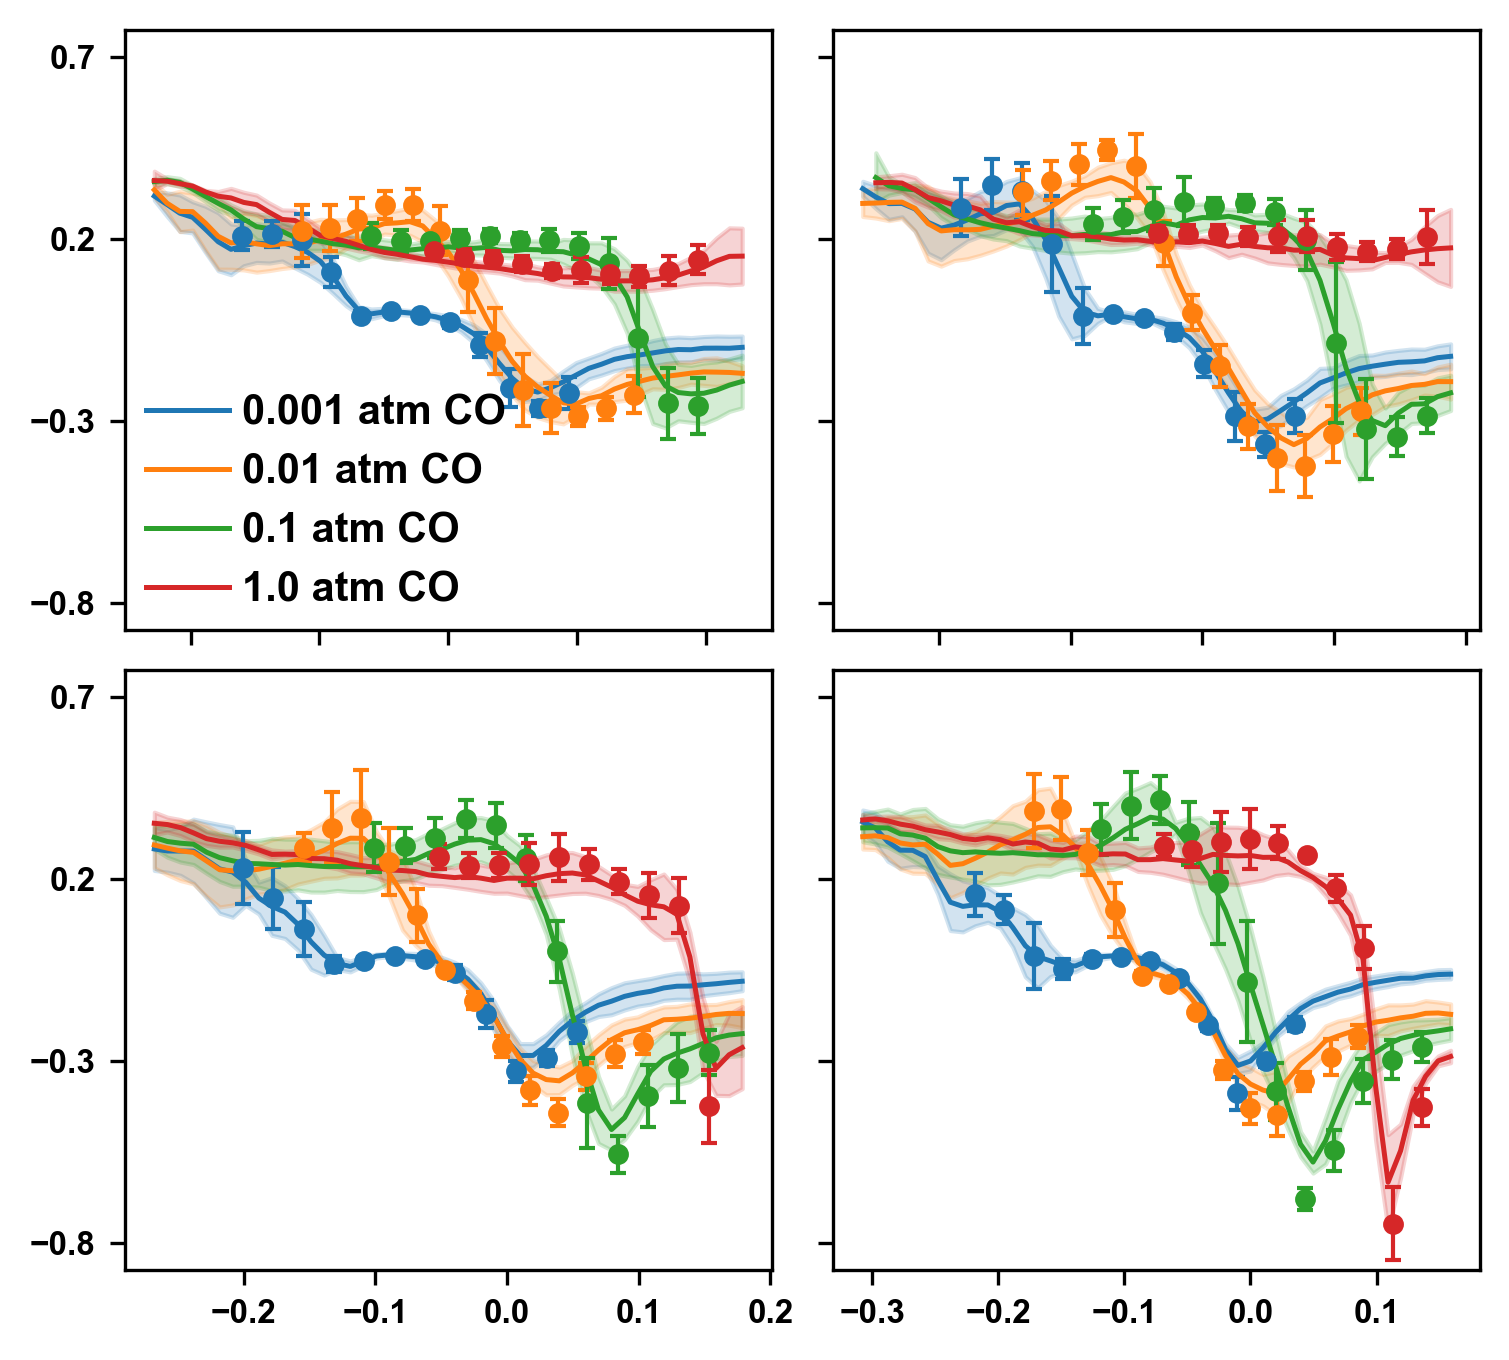

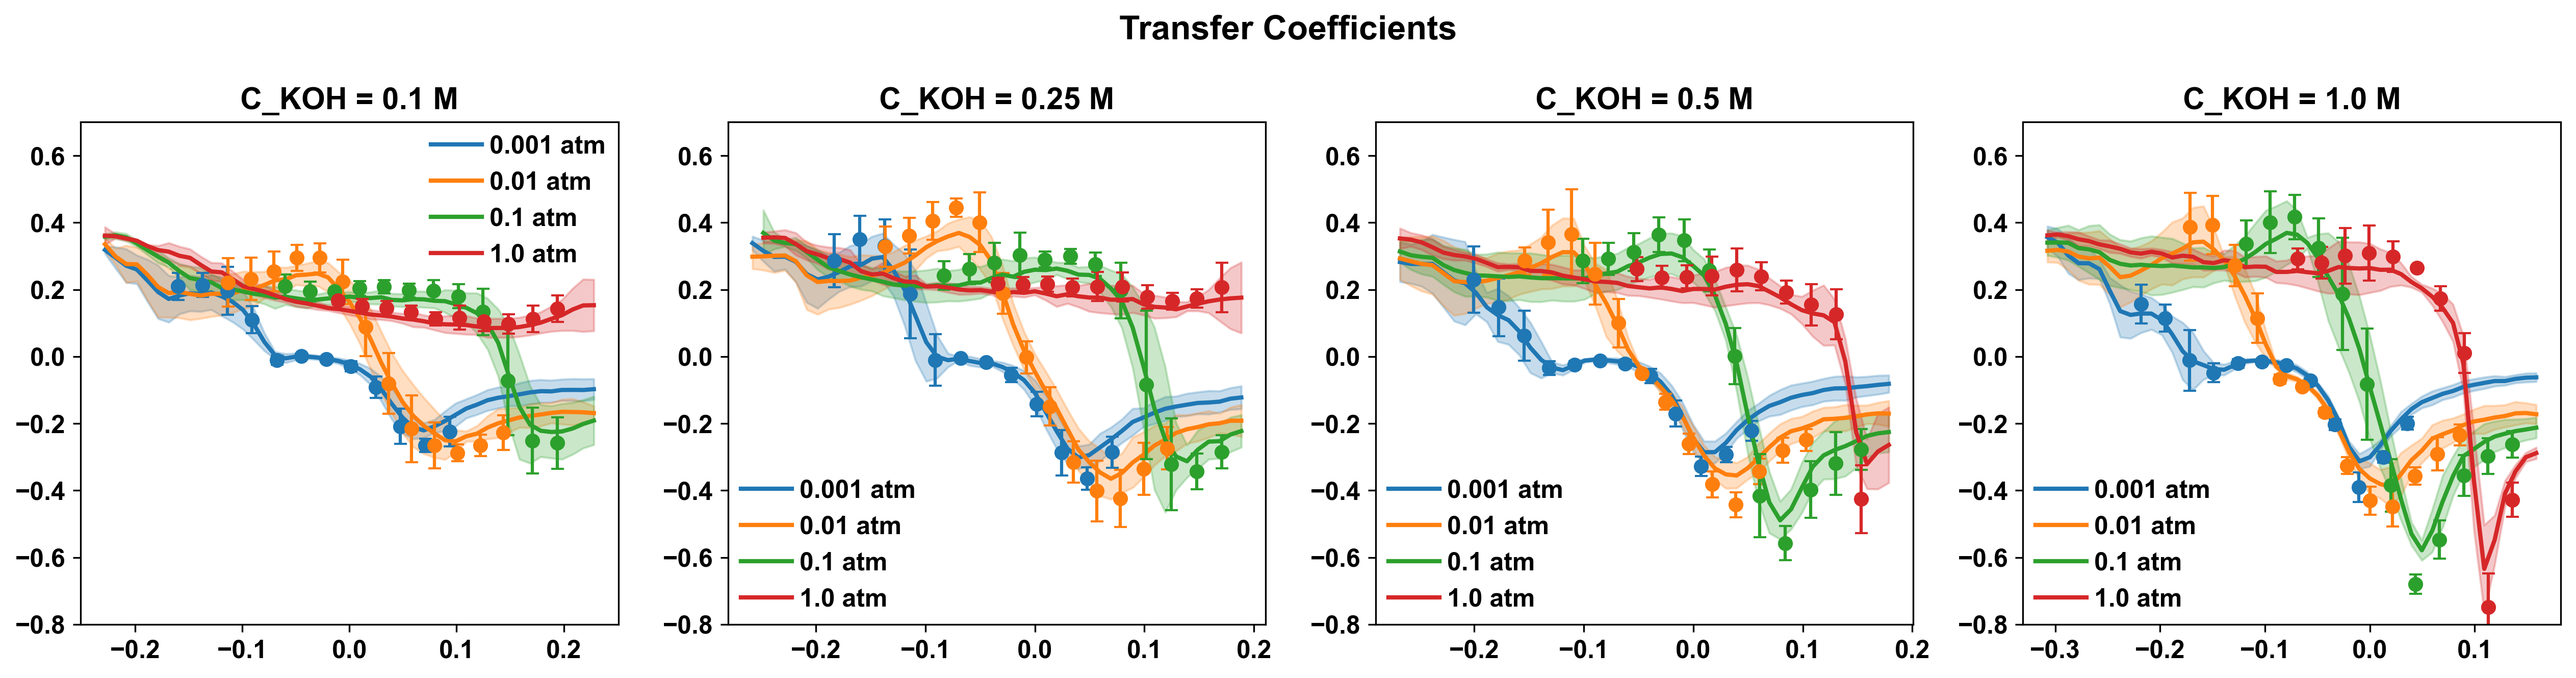

In [9]:

# Plotting alphas 

fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1) 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['untruncated_E'] 
        alpha = experiments_mean[condition]['untruncated_alpha'] 
        alpha_SD = experiments_mean[condition]['untruncated_alpha_SD']
        line = ax.plot(E, alpha, label=f'{P_CO} atm CO', linewidth=1.2)
        ax.fill_between(E, alpha - alpha_SD, alpha + alpha_SD, color=line[0].get_color(), alpha=0.2)
        
        E_todd = alpha_todd[condition]['E']
        alpha_todd_val = alpha_todd[condition]['alpha']
        alpha_todd_SD = alpha_todd[condition]['alpha_SD']
        ax.errorbar(E_todd, alpha_todd_val, yerr=alpha_todd_SD, fmt='o', markersize=4, color=line[0].get_color(), capsize=2, elinewidth=1.0)
        
    span = 0.7 - (-0.8)
    margin = 0.05 * span
    
    ax.set_yticks([-0.8, -0.3, 0.2, 0.7])
    ax.set_ylim(-0.8 - margin, 0.7 + margin)
    ax.tick_params(axis='both', labelsize=8)
    
    if i < 2: ax.tick_params(labelbottom=False)
    if i % 2 != 0: ax.tick_params(labelleft=False)
    
    if i == 0: ax.legend(fontsize=10, frameon=False, loc='lower left')

plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Transfer Coefficients', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {C_KOH} M') 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['untruncated_E'] 
        alpha = experiments_mean[condition]['untruncated_alpha'] 
        alpha_SD = experiments_mean[condition]['untruncated_alpha_SD']
        line = ax.plot(E, alpha, label=f'{P_CO} atm', linewidth=2)
        ax.fill_between(E, alpha - alpha_SD, alpha + alpha_SD, color=line[0].get_color(), alpha=0.25)
        
        E_todd = alpha_todd[condition]['E']
        alpha_todd_val = alpha_todd[condition]['alpha']
        alpha_todd_SD = alpha_todd[condition]['alpha_SD']
        ax.errorbar(E_todd, alpha_todd_val, yerr=alpha_todd_SD, fmt='o', markersize=6, color=line[0].get_color(), capsize=3, elinewidth=1.5)
        
    ax.set_ylim(-0.8, 0.7)
    ax.legend()
plt.tight_layout()

In [10]:
# Load Todd's delta_OH data + classification

delta_OH_todd_raw = pd.read_excel(excel_file, sheet_name='OH- Order')
delta_OH_todd = {}
for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 3
    subset = delta_OH_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'delta_OH', 'delta_OH_SD'] # in SHE
    subset = subset.dropna()
    delta_OH_todd[(P_CO)] = subset

In [11]:
# Block 6: Calculate delta_OH from UNTRUNCATED data # CHANGED

for P_CO in P_CO_list:
    for trial in trials:
        # CHANGED: Because E_ref shifts bounds, dynamically locate the overlapping SHE grid points across all KOH concentrations
        common_E = None
        for C_KOH in C_KOH_list:
            E_SHE = untruncated_data[(C_KOH, P_CO, trial)]['E']
            if common_E is None:
                common_E = set(np.round(E_SHE, 6))
            else:
                common_E = common_E.intersection(np.round(E_SHE, 6))
        
        common_E = np.sort(list(common_E))
        
        # CHANGED: Extract log rates exactly at the unified intersecting SHE grid points
        log_rate_matrix = []
        for C_KOH in C_KOH_list:
            E_SHE = np.round(untruncated_data[(C_KOH, P_CO, trial)]['E'], 6)
            lr = untruncated_data[(C_KOH, P_CO, trial)]['log_rate']
            mask = np.isin(E_SHE, common_E)
            log_rate_matrix.append(lr[mask])
            
        log_rate_matrix = np.array(log_rate_matrix) # Shape: (len(C_KOH_list), len(common_E))
        
        # CHANGED: Replaced messy element-wise deltas with polyfit directly on log rates for physical robustness
        delta_OH = np.polyfit(np.log(C_KOH_list), log_rate_matrix, deg=1)[0]
        
        for C_KOH in C_KOH_list: 
            untruncated_data[(C_KOH, P_CO, trial)]['delta_OH'] = delta_OH 
            untruncated_data[(C_KOH, P_CO, trial)]['common_E_OH'] = common_E # CHANGED

for condition in conditions: 
    C_KOH, P_CO = condition
    delta_OH_trials = [untruncated_data[(C_KOH, P_CO, trial)]['delta_OH'] for trial in trials]
    delta_OH_array = np.array(delta_OH_trials)
    
    # CHANGED: Saved under specific plotting keys to avoid colliding with truncated arrays
    experiments_mean[condition]['untruncated_E_OH'] = untruncated_data[(C_KOH, P_CO, 1)]['common_E_OH'] 
    experiments_mean[condition]['untruncated_delta_OH'] = np.mean(delta_OH_array, axis=0) 
    experiments_mean[condition]['untruncated_delta_OH_SD'] = np.std(delta_OH_array, axis=0, ddof=1)

# OH Reaction Order

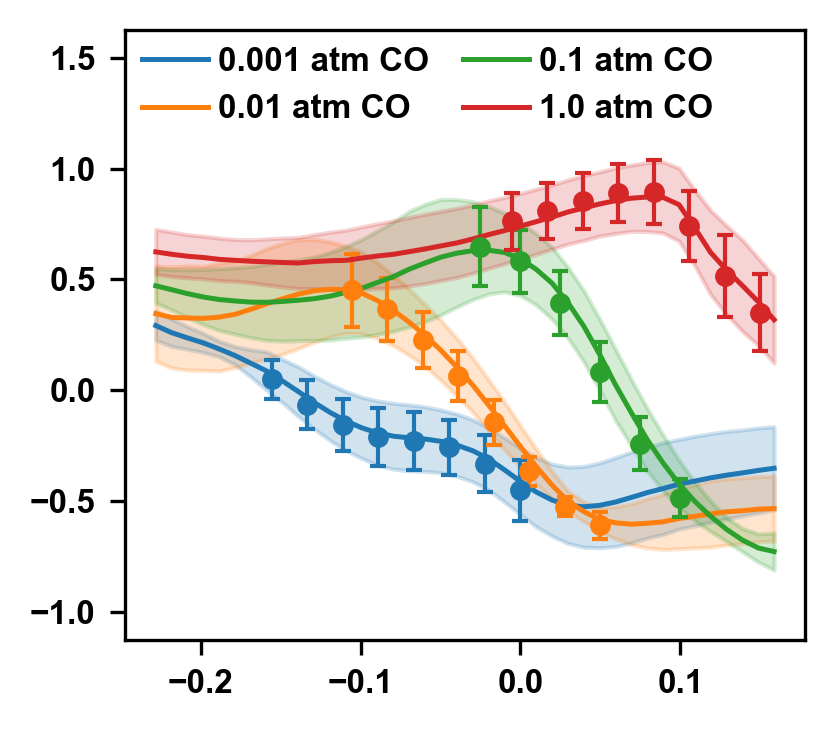

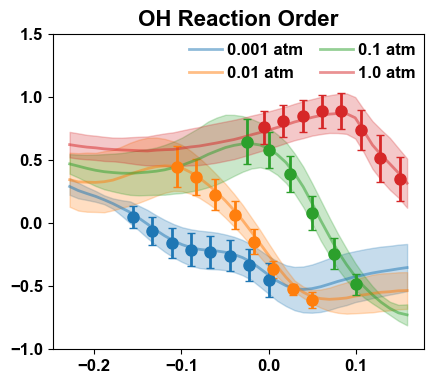

In [12]:
# Plotting delta_OH


fig = plt.figure(figsize=(2.75, 2.4), dpi=300)
ax = plt.subplot(1, 1, 1)
for P_CO in P_CO_list:
    delta_OH = experiments_mean[(C_KOH_list[1], P_CO)]['untruncated_delta_OH'] 
    delta_OH_SD = experiments_mean[(C_KOH_list[1], P_CO)]['untruncated_delta_OH_SD'] 
    E_SHE = experiments_mean[(C_KOH_list[1], P_CO)]['untruncated_E_OH'] 
    line = ax.plot(E_SHE, delta_OH, label=f'{P_CO} atm CO', linewidth=1.2) 
    ax.fill_between(E_SHE, delta_OH - delta_OH_SD, delta_OH + delta_OH_SD, color=line[0].get_color(), alpha=0.2)
    E_todd = delta_OH_todd[(P_CO)]['E']
    delta_OH_todd_val = delta_OH_todd[(P_CO)]['delta_OH']
    delta_OH_todd_SD = delta_OH_todd[(P_CO)]['delta_OH_SD']
    ax.errorbar(E_todd, delta_OH_todd_val, yerr=delta_OH_todd_SD, fmt='o', markersize=4, color=line[0].get_color(), capsize=2, elinewidth=1.0)
span = 1.5 - (-1.0)
margin = 0.05 * span
ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
ax.set_ylim(-1.0 - margin, 1.5 + margin)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8, frameon=False, loc='upper left', ncols=2)
plt.tight_layout(pad=0.5)
plt.show()


fig = plt.figure(figsize=(4.5, 4), dpi=100)
plt.title('OH Reaction Order', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    delta_OH = experiments_mean[(C_KOH_list[1], P_CO)]['untruncated_delta_OH'] 
    delta_OH_SD = experiments_mean[(C_KOH_list[1], P_CO)]['untruncated_delta_OH_SD'] 
    E_SHE = experiments_mean[(C_KOH_list[1], P_CO)]['untruncated_E_OH']
    line, = plt.plot(E_SHE, delta_OH, label=f'{P_CO} atm', alpha=0.5) 
    plt.fill_between(E_SHE, delta_OH - delta_OH_SD, delta_OH + delta_OH_SD, color=line.get_color(), alpha=0.25)
    E_todd = delta_OH_todd[(P_CO)]['E']
    delta_OH_todd_val = delta_OH_todd[(P_CO)]['delta_OH']
    delta_OH_todd_SD = delta_OH_todd[(P_CO)]['delta_OH_SD']
    plt.errorbar(E_todd, delta_OH_todd_val, yerr=delta_OH_todd[(P_CO)]['delta_OH_SD'], fmt='o', markersize=8, color=line.get_color())
plt.legend(ncols=2)
plt.ylim(-1, 1.5)
plt.tight_layout()

In [13]:
# Load Todd's delta_CO data + classification

delta_CO_todd_raw = pd.read_excel(excel_file, sheet_name='CO order')
delta_CO_todd = {}
conditions_delta_CO = list(itertools.product(C_KOH_list, P_CO_list[0:-1]))
for i, (C_KOH, P_CO) in enumerate(conditions_delta_CO):
    col_idx = i * 3
    subset = delta_CO_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'delta_CO', 'delta_CO_SD'] # in RHE
    subset = subset.dropna()
    delta_CO_todd[(C_KOH, P_CO)] = subset

    E_ref = 0 - slope_f*(14 + np.log10(C_KOH))
    delta_CO_todd[(C_KOH, P_CO)]['E'] = delta_CO_todd[(C_KOH, P_CO)]['E'] + E_ref

In [14]:
# Block 7: Calculate delta_CO from UNTRUNCATED data (Point-to-point differences)

for C_KOH in C_KOH_list:
    for trial in trials: 
        # Iterate through adjacent pairs to get point-to-point differences
        for i in range(len(P_CO_list) - 1):
            P_CO_1 = P_CO_list[i]
            P_CO_2 = P_CO_list[i+1]
            
            # CHANGED: Extract the SHE grids for the two adjacent pressures
            E_1 = np.round(untruncated_data[(C_KOH, P_CO_1, trial)]['E'], 6)
            E_2 = np.round(untruncated_data[(C_KOH, P_CO_2, trial)]['E'], 6)
            
            # CHANGED: Find the exact overlapping grid points
            common_E = np.intersect1d(E_1, E_2)
            
            # CHANGED: Mask the log_rates so they are the exact same shape/alignment
            mask_1 = np.isin(E_1, common_E)
            mask_2 = np.isin(E_2, common_E)
            
            ln_j_1 = untruncated_data[(C_KOH, P_CO_1, trial)]['log_rate'][mask_1]
            ln_j_2 = untruncated_data[(C_KOH, P_CO_2, trial)]['log_rate'][mask_2]
            
            # Point-to-point reaction order
            delta_CO = (ln_j_2 - ln_j_1) / np.log(P_CO_2 / P_CO_1)
            
            # Store it under the "lower" pressure condition
            untruncated_data[(C_KOH, P_CO_1, trial)]['delta_CO'] = delta_CO
            untruncated_data[(C_KOH, P_CO_1, trial)]['common_E_CO'] = common_E

# Calculate means and SDs
for C_KOH in C_KOH_list:
    for i in range(len(P_CO_list) - 1):
        P_CO_1 = P_CO_list[i]
        condition = (C_KOH, P_CO_1)
        
        delta_CO_trials = [untruncated_data[(C_KOH, P_CO_1, trial)]['delta_CO'] for trial in trials]
        delta_CO_array = np.array(delta_CO_trials)
        
        # Save explicitly for plotting
        experiments_mean[condition]['untruncated_E_CO'] = untruncated_data[(C_KOH, P_CO_1, 1)]['common_E_CO']
        experiments_mean[condition]['untruncated_delta_CO'] = np.mean(delta_CO_array, axis=0) 
        experiments_mean[condition]['untruncated_delta_CO_SD'] = np.std(delta_CO_array, axis=0, ddof=1)

# CO Reaction Order

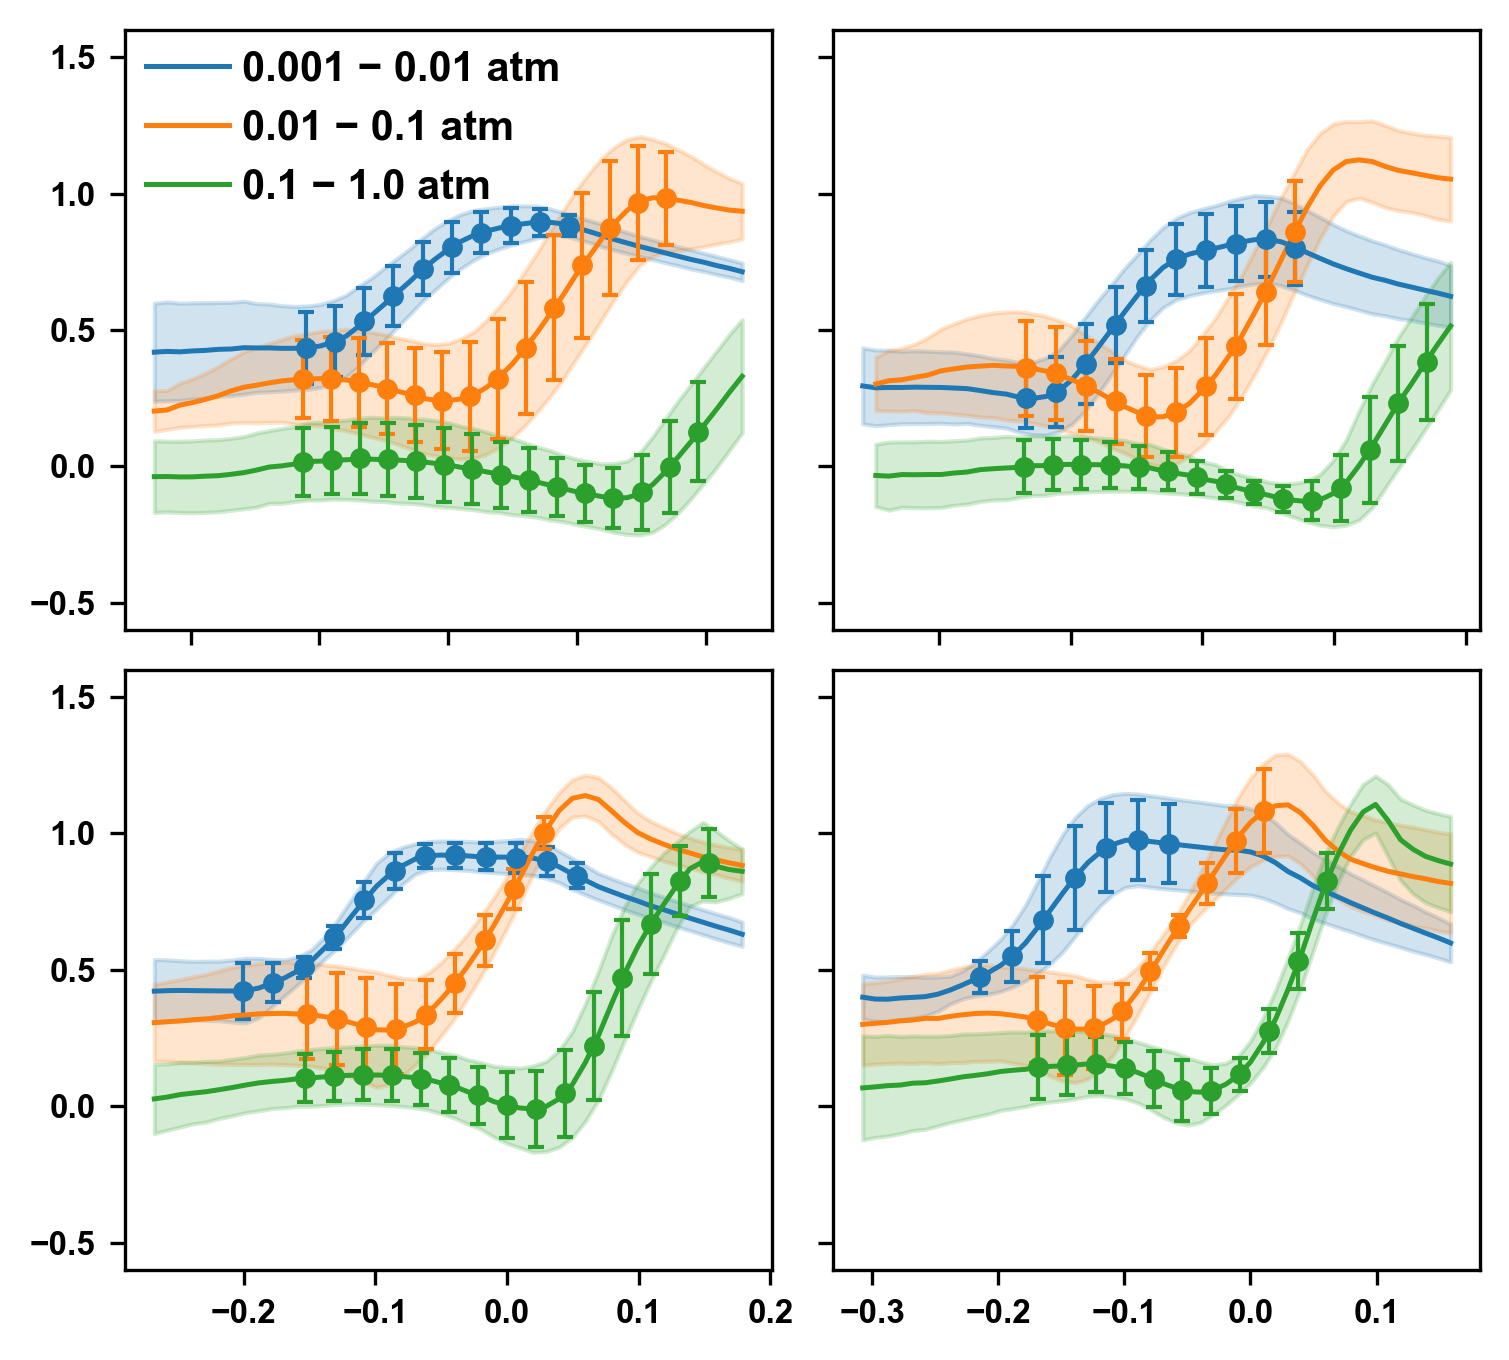

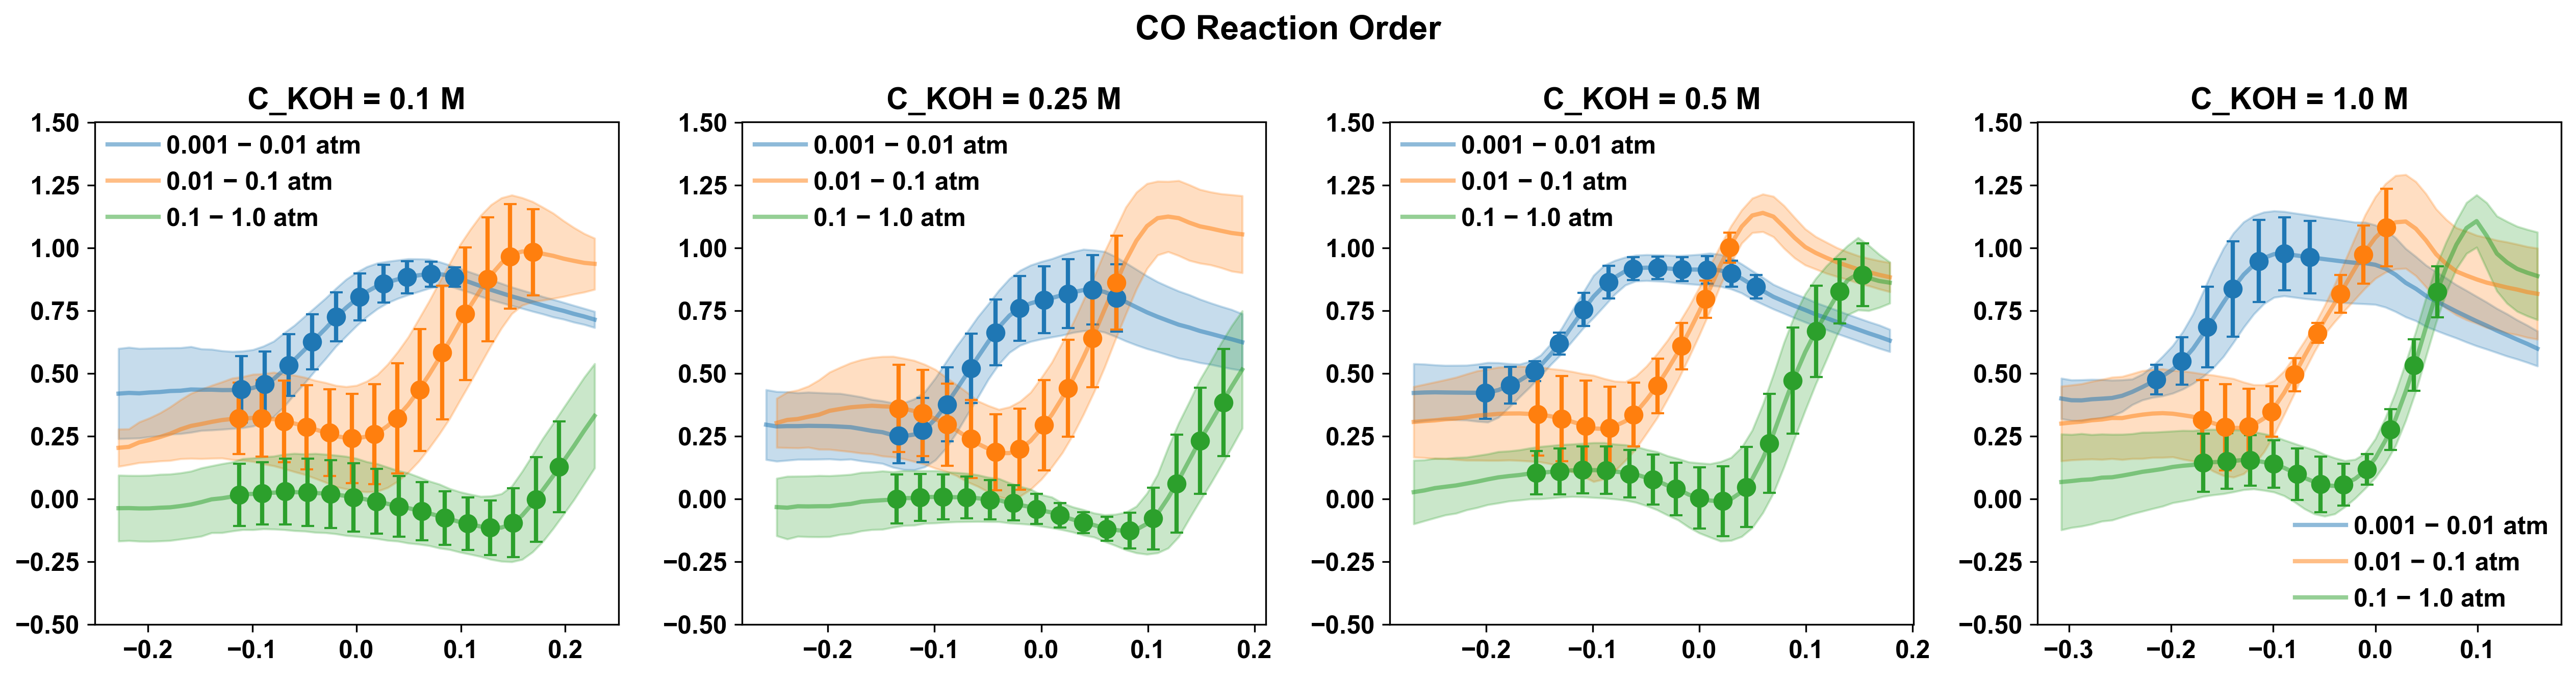

In [15]:
# Plotting delta_CO

fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, target_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1)
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            E = experiments_mean[(C_KOH, P_CO)]['untruncated_E_CO']
            delta_CO = experiments_mean[(C_KOH, P_CO)]['untruncated_delta_CO']
            delta_CO_SD = experiments_mean[(C_KOH, P_CO)]['untruncated_delta_CO_SD']
            # Find the next P_CO for the label
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            line = ax.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', linewidth=1.2)
            ax.fill_between(E, delta_CO - delta_CO_SD, delta_CO + delta_CO_SD, color=line[0].get_color(), alpha=0.2)
            E_todd = delta_CO_todd[(C_KOH, P_CO)]['E']
            delta_CO_todd_val = delta_CO_todd[(C_KOH, P_CO)]['delta_CO']
            delta_CO_todd_SD = delta_CO_todd[(C_KOH, P_CO)]['delta_CO_SD']
            ax.errorbar(E_todd, delta_CO_todd_val, yerr=delta_CO_todd_SD, fmt='o', markersize=4, color=line[0].get_color(), capsize=2, elinewidth=1.0)
    # 5% floating margin
    span = 1.5 - (-0.5)
    margin = 0.05 * span
    ax.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    ax.set_ylim(-0.5 - margin, 1.5 + margin)
    ax.tick_params(axis='both', labelsize=8)
    # Share axes visually by hiding inner tick labels
    if i < 2: ax.tick_params(labelbottom=False)
    if i % 2 != 0: ax.tick_params(labelleft=False)
    # Legend only in the first plot
    if i == 0:
        ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('CO Reaction Order', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            E = experiments_mean[(C_KOH, P_CO)]['untruncated_E_CO']
            delta_CO = experiments_mean[(C_KOH, P_CO)]['untruncated_delta_CO']
            delta_CO_SD = experiments_mean[(C_KOH, P_CO)]['untruncated_delta_CO_SD']
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            line, = plt.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', alpha=0.5)
            plt.fill_between(E, delta_CO - delta_CO_SD, delta_CO + delta_CO_SD, color=line.get_color(), alpha=0.25)
            
            E_todd = delta_CO_todd[(C_KOH, P_CO)]['E']
            delta_CO_todd_val = delta_CO_todd[(C_KOH, P_CO)]['delta_CO']
            delta_CO_todd_SD = delta_CO_todd[(C_KOH, P_CO)]['delta_CO_SD']
            plt.errorbar(E_todd, delta_CO_todd_val, yerr=delta_CO_todd_SD, fmt='o', markersize=8, color=line.get_color(), capsize=3)

    plt.legend()
    plt.ylim(-0.5, 1.5)
plt.tight_layout()

In [16]:
import pickle

with open('import_Pt100_KOH_replicates.pkl', 'wb') as f:
    pickle.dump(experiments_mean, f)